In [1]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np

from nre.preprocess import preprocess_df
from nre.network_connectivity import ConnectivityUnit
from nre.analyze_nf_dataset import nre_classification, flow_based_classification
from nre.classification_tools import plot_roc_curves
from nre.network_partitioning import apply_spec_clus

from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB


In [2]:

# CIC-IDS-2017
file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Tuesday-WorkingHours.pcap_ISCX.csv'  # 'Monday-WorkingHours.pcap_ISCX.csv' #  Wednesday-workingHours.pcap_ISCX.csv
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Friday-WorkingHours-Morning.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'
#file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'

# NF-ToN-IoT
file_addr = r'..\..\NF-ToN-IoT\NF-ToN-IoT-v3-small.csv'

# Definitions
date_col = 'FLOW_START_MILLISECONDS' # 'FLOW_START_MILLISECONDS' # ' Timestamp'
label_col = 'Label' # 'Label' # ' Label'
src_id_col = 'IPV4_SRC_ADDR' # ' Source IP'
dst_id_col = 'IPV4_DST_ADDR' # ' Total Backward Packets'
src_feature_col = 'OUT_PKTS' # ' Total Fwd Packets'
dst_feature_col = 'IN_PKTS' # ' Total Backward Packets'
conn_param = 'NPS'

In [3]:
#df_cic = pd.read_csv(file_addr, header=0, encoding='cp1252')
df_iot = pd.read_csv(file_addr, sep=',', encoding='utf-8')

#df = preprocess_df(df_cic, date_col=' Timestamp')
df_whole = preprocess_df(df_iot, date_col=date_col)

print(df_whole.shape)

(507190, 55)


# Train - Test Split
Use the same split (seed) in experiment section

In [4]:
seed = 138
test_size = 0.33

ind_co = int(df_whole.shape[0] * (1 - test_size))
df_train, df_test = df_whole.iloc[:ind_co, :], df_whole.iloc[ind_co:, :]

df = df_train
print(df.shape)

(339817, 55)


# Network Scope 

## CIC-IDS-2017

In [5]:
with open(r'saves\monday_freq_1000.pickle', 'rb') as handle:
    entity_names = pickle.load(handle) 
len(entity_names)

991

## NF-ToN-IoT

In [36]:
with open(r'saves/ton_iot_small_freq_0.pickle', 'rb') as handle:
    entity_names = pickle.load(handle) 
len(entity_names)

316

In [7]:
df = df_train
#df = df_whole.iloc[:200_000] # 150_000
idx = df[src_id_col].isin(entity_names) & df[dst_id_col].isin(entity_names)
#df = df[idx].copy()
df.shape

(339817, 55)

In [8]:
import importlib
import nre.network_connectivity

importlib.reload(nre.network_connectivity)
from nre.network_connectivity import *

Conditioning number:  9.670948102424662e+18 
Determinant of F^T*F:  -3.093864060126532e-100


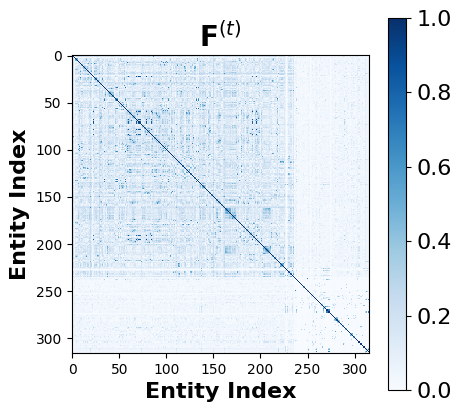

<Figure size 640x480 with 0 Axes>

In [30]:
kwargs = {'date_col':date_col, 'src_id_col': src_id_col, 'dst_id_col': dst_id_col, 'conn_param':conn_param,
          'window_type':'conn', 'conn_size':500}
#kwargs = {'date_col':date_col, 'src_id_col': src_id_col, 'dst_id_col': dst_id_col, 
#          'conn_param':conn_param, window_type= 'time', sync_window_size= 20, time_scale= 'sec'} # 20s


cu = ConnectivityUnit(conn_param_specs=ton_iot_conn_param_specs)
cu.read_flows(df, **kwargs) 
cu.fit_connectivity_model(method = 'cov') # cov
cu.plot_f()

In [31]:
df

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,...,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
0,1970-01-01 00:25:56.030,1556030000000.0,192.168.1.32,41315,192.168.1.169,10010,6,0,44,1,...,0,0,0,0,0,0,0,0,0,Benign
338134,1970-01-01 00:25:56.030,1556030000000.0,192.168.1.31,39518,192.168.35.248,443,6,91,44,1,...,0,0,0,0,0,0,0,0,1,scanning
338133,1970-01-01 00:25:56.030,1556030000000.0,192.168.1.31,39518,192.168.35.247,443,6,91,44,1,...,0,0,0,0,0,0,0,0,1,scanning
338132,1970-01-01 00:25:56.030,1556030000000.0,192.168.1.31,39518,192.168.35.246,443,6,91,44,1,...,0,0,0,0,0,0,0,0,1,scanning
338131,1970-01-01 00:25:56.030,1556030000000.0,192.168.1.31,35309,192.168.35.158,80,6,7,40,1,...,0,0,0,0,0,0,0,0,1,scanning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2344,1970-01-01 00:25:56.030,1556030000000.0,192.168.1.31,58245,192.168.1.169,3689,6,0,44,1,...,0,0,0,0,0,0,0,0,0,Benign
2343,1970-01-01 00:25:56.030,1556030000000.0,192.168.1.31,58245,192.168.1.46,2105,6,0,44,1,...,0,0,0,0,0,0,0,0,0,Benign
2342,1970-01-01 00:25:56.030,1556030000000.0,192.168.1.31,58245,192.168.1.195,5679,6,0,44,1,...,0,0,0,0,0,0,0,0,0,Benign
2341,1970-01-01 00:25:56.030,1556030000000.0,192.168.1.32,43918,192.168.1.180,2007,6,0,44,1,...,0,0,0,0,0,0,0,0,0,Benign


In [32]:
cu.samples.shape

(679, 316)

In [33]:
np.max(cu.mat_f - np.diag(np.diag(cu.mat_f)))

1.0

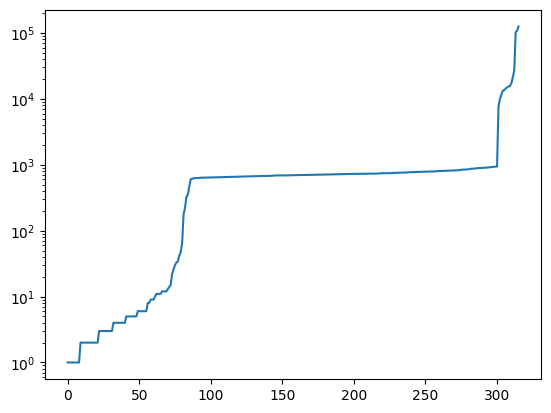

In [34]:
plt.semilogy(np.sort(cu.num_appearances))

In [ ]:
import importlib, src
import src.network_connectivity

importlib.reload(src.network_connectivity)
from src.network_connectivity import*

In [28]:
count_thr = 1000
cu.remove_infrequent(thr=count_thr)
entity_names = cu.names
print(len(entity_names))
with open('saves/ton_iot_small_freq_{}.pickle'.format(count_thr), 'wb') as handle:
    pickle.dump(entity_names, handle, protocol=pickle.HIGHEST_PROTOCOL)

15


In [6]:
victim_names = [ '192.168.10.3',
                 '192.168.10.50',
                 '192.168.10.51',
                 '192.168.10.19',
                 '192.168.10.17',
                 '192.168.10.16',
                 '192.168.10.12',
                 '192.168.10.9',
                 '192.168.10.5',
                 '192.168.10.8',
                 '192.168.10.14',
                 '192.168.10.15',
                 '192.168.10.25']

with open('victim_net.pickle', 'wb') as handle:
    pickle.dump(victim_names, handle, protocol=pickle.HIGHEST_PROTOCOL)
len(victim_names)

13

# Partitioning

Conditioning number:  1.7596484224422176e+17 
Determinant of F^T*F:  -1.0452100277944993e-43


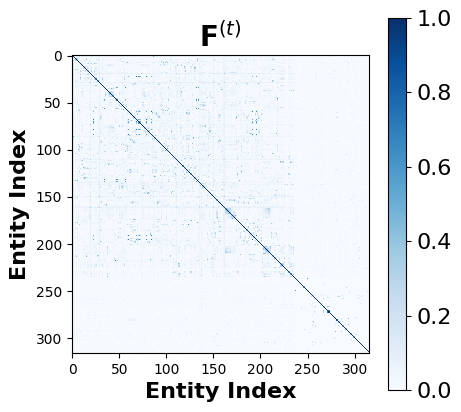

<Figure size 640x480 with 0 Axes>

In [49]:
kwargs = {'date_col':date_col, 'src_id_col': src_id_col, 'dst_id_col': dst_id_col, 'conn_param':conn_param,
          'window_type':'conn', 'conn_size':50}
#kwargs = {'date_col':date_col, 'src_id_col': src_id_col, 'dst_id_col': dst_id_col, 
#          'conn_param':conn_param, window_type= 'time', sync_window_size= 20, time_scale= 'sec'} # 20s


cu = ConnectivityUnit(conn_param_specs=ton_iot_conn_param_specs) # conn_param_specs=ton_iot_conn_param_specs
cu.read_flows(df, entity_names=entity_names, **kwargs) # 1.2
cu.fit_connectivity_model(method = 'cov') # cov
cu.plot_f()

In [45]:
import importlib
import nre.network_partitioning

importlib.reload(nre.network_partitioning)
from nre.network_partitioning import*

In [46]:
import nre.network_connectivity, importlib

importlib.reload(nre.network_connectivity)
from nre.network_connectivity import*

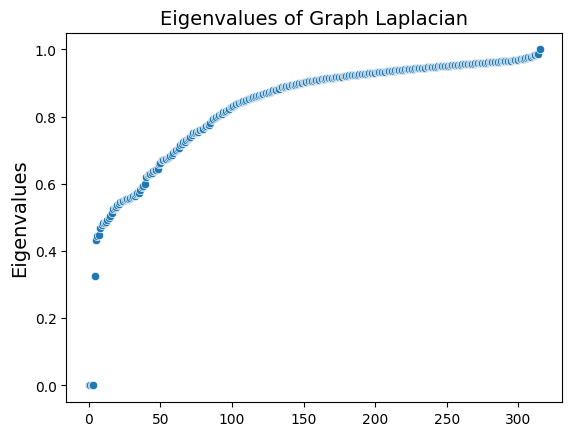

0.9982496588634914
[0.00000000e+00 0.00000000e+00 0.00000000e+00 1.51238569e-17
 3.24355276e-01 4.32748741e-01 4.44416435e-01 4.47396617e-01
 4.68089639e-01 4.78815352e-01]


In [50]:
eigvals, err = get_eig_vals_err(cu.mat_f, cu.names)

print(err)
print(eigvals[:10])

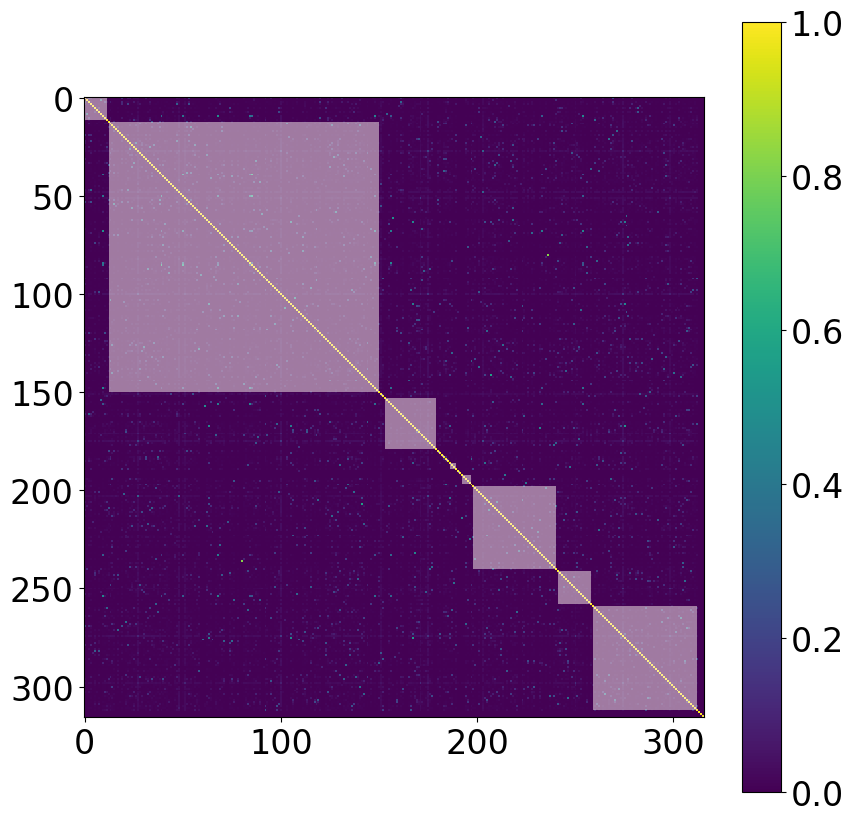

In [48]:
gr, new_labels, clusters = apply_spec_clus(cu.mat_f, cu.names, 3, fontsize = 24) # 13

In [46]:
sublist = apply_partitioning(cu, 3, plot_bool=False)

In [47]:
sublist[2].names

['192.168.35.208',
 '192.168.35.205',
 '192.168.35.51',
 '192.168.35.64',
 '192.168.35.53',
 '192.168.35.148',
 '192.168.35.88',
 '192.168.35.94',
 '192.168.35.43',
 '192.168.35.231',
 '192.168.35.90',
 '192.168.35.76',
 '192.168.1.190',
 '192.168.35.229',
 '192.168.35.176',
 '192.168.1.1',
 '192.168.35.100',
 '192.168.35.97',
 '192.168.35.40',
 '192.168.35.222',
 '239.255.255.250',
 '103.76.40.123',
 '84.53.139.64',
 '199.7.83.42',
 '95.100.168.32',
 '192.82.134.30',
 '23.211.61.67',
 '101.119.11.11',
 '184.84.165.131',
 '184.26.160.67',
 '95.100.173.67',
 '95.101.36.32',
 '35.244.179.255']

In [48]:
new_labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

66.66666666666666 % of the victim nodes are in one cluster for n= 2  clusters
Total size of the subnet:  2585
33.33333333333333 % of the victim nodes are in one cluster for n= 5  clusters
Total size of the subnet:  1093
26.666666666666668 % of the victim nodes are in one cluster for n= 8  clusters
Total size of the subnet:  398
26.666666666666668 % of the victim nodes are in one cluster for n= 11  clusters
Total size of the subnet:  616


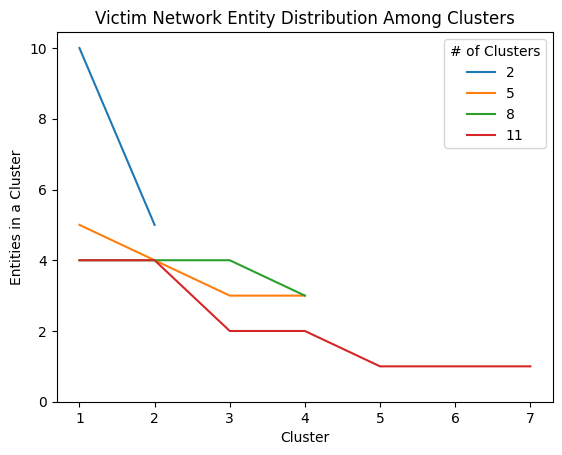

In [51]:
with open(r'saves/ton_iot_small_freq_1000.pickle', 'rb') as handle: # saves/ton_iot_small_freq_{} # saves\victim_net.pickle
    victim_network = pickle.load(handle) 

plt.rcParams.update({'font.size': 10})
ax = plt.subplot()
num_clusters = np.arange(2, 14, 3) # 21, 135, 10
for i in num_clusters:
    ggr, new_labels, clusters = apply_spec_clus(cu.mat_f, cu.names, i, plot_bool=False)
    clus_assign = get_clus_assign(victim_network, ggr, new_labels)
    _, inv_arr, counts = np.unique(list(clus_assign.values()), return_inverse=True, return_counts= True)
    _, clus_sizes = np.unique(new_labels, return_counts= True)
    sub_net_size = np.sum(clus_sizes[inv_arr])
    print( max(counts)/len(clus_assign) * 100, '% of the victim nodes are in one cluster for n=', i, ' clusters')
    print('Total size of the subnet: ', sub_net_size)
    
    plt.plot(np.arange(1, len(counts)+1).astype(int), np.sort(counts)[::-1], label=str(i))
    
plt.ylim([0, ax.get_ylim()[1]])
plt.title('Victim Network Entity Distribution Among Clusters')
plt.xlabel('Cluster')
plt.ylabel('Entities in a Cluster')
plt.legend(title='# of Clusters')
plt.show()

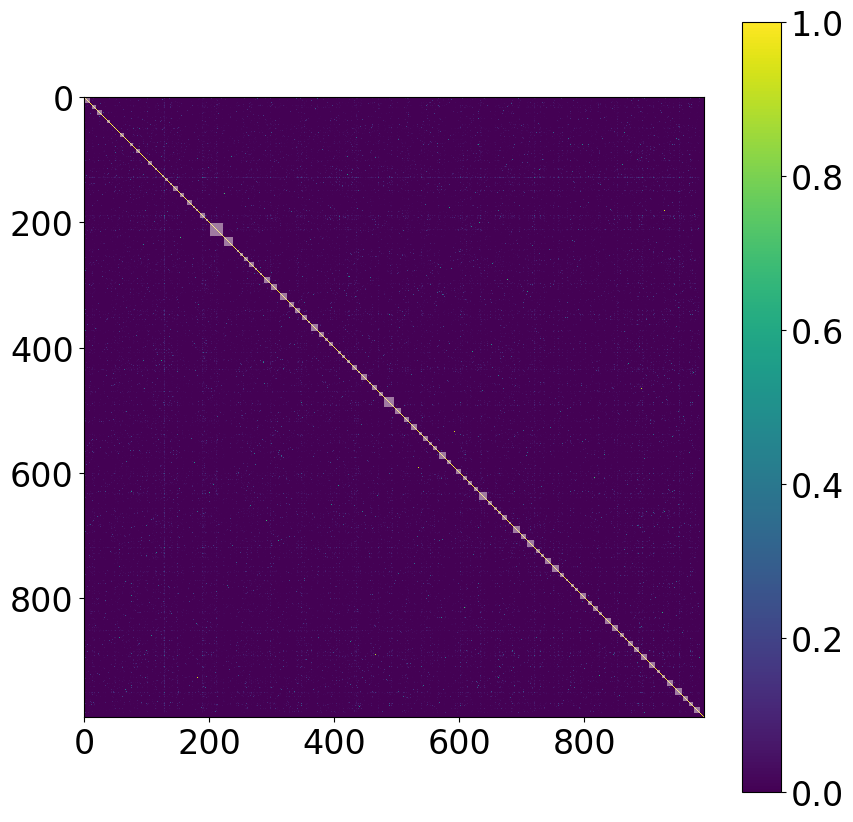

[  2  31  33  44  48  59  60  65  93 106 117 120]


(141,)

In [9]:
gr, new_labels, clusters = apply_spec_clus(cu.F, cu.names, 121, fontsize = 24, plot_bool=True) # 48
clus_assign = get_clus_assign(victim_network, gr, new_labels)
plt.rcParams.update({'font.size': 10})

target_clusters = np.unique(list(clus_assign.values()))
print(target_clusters)
idx = np.where(np.isin(new_labels, target_clusters))
np.array(list(gr.nodes))[idx].shape

Cluster 32
Conditioning number:  1.5423555573659935 
Determinant of F^T*F:  0.9990258184889945


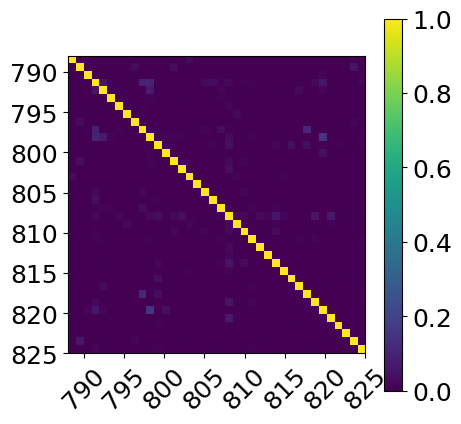

In [25]:
hr = get_graph_clus(gr, new_labels, clusters, 32, fontsize = 18) #8

In [10]:
calc_nodes = list(np.array(list(gr.nodes))[idx])
len(calc_nodes)

141

In [11]:
with open('saves//partitioned_nodes_141.pickle', 'wb') as handle: # sample_nodes.pickle
    pickle.dump(calc_nodes, handle, protocol=pickle.HIGHEST_PROTOCOL)


In [35]:
with open('saves//partitioned_nodes_377.pickle', 'rb') as handle:
    calc_nodes = pickle.load(handle) 

Conditioning number:  6.2631373693744194 
Determinant of F^T*F:  0.8338238077600261


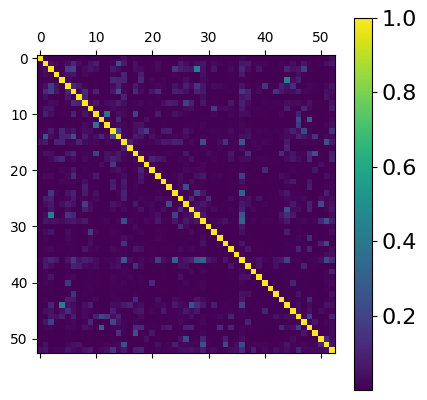

In [20]:
cu = ConnectivityUnit()
cu.read_flows(df, entity_names=calc_nodes, conn_param='Num Packets Rec', window_type= 'time', time_scale= 'sec')
cu.fit_graph_model(method = 'cov') # cov
cu.plot_f()
plt.show()

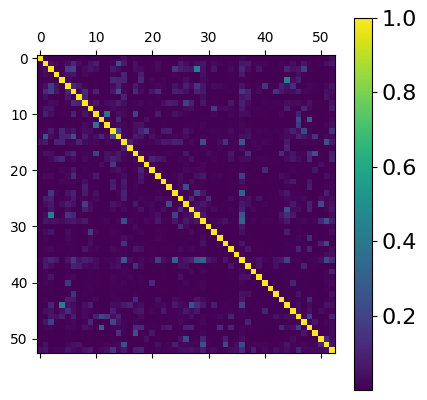

In [19]:
plt.show()

In [11]:
# Subgraphs
cond_dict = {}
nodes = np.array(list(gr.nodes))

for i, cluster in enumerate(clusters):
    ind = new_labels == cluster
    Hr = gr.subgraph(nodes[ind]).copy()
    A = nx.adjacency_matrix(Hr).todense()
    K = np.linalg.cond(A)
    d = np.linalg.det(A.T * A)
    print('Cluster '  + str(i) + '\nConditioning number: ', K, '\nDeterminant of F^T*F: ', d)
    cond_dict[cluster] = K

print(max(list(cond_dict.values())))

Cluster 0
Conditioning number:  1.1858079016188734 
Determinant of F^T*F:  0.9999509768996137
Cluster 1
Conditioning number:  1.0294947658530602 
Determinant of F^T*F:  0.9999999603357204
Cluster 2
Conditioning number:  1.1944283365259754 
Determinant of F^T*F:  0.9999504530706593
Cluster 3
Conditioning number:  1.3851247573190386 
Determinant of F^T*F:  0.9995373296610679
Cluster 4
Conditioning number:  1.187243119255009 
Determinant of F^T*F:  0.9999585950942437
Cluster 5
Conditioning number:  1.1695734942722704 
Determinant of F^T*F:  0.9999773837267613
Cluster 6
Conditioning number:  1.0050491612881451 
Determinant of F^T*F:  0.9999999999597861
Cluster 7
Conditioning number:  1.3485043225054048 
Determinant of F^T*F:  0.999732178800987
Cluster 8
Conditioning number:  1.0212322164520042 
Determinant of F^T*F:  0.9999999953208559
Cluster 9
Conditioning number:  1.372162249530943 
Determinant of F^T*F:  0.9997058902627208
Cluster 10
Conditioning number:  1.0136789643963764 
Determinan

Cluster 113
Conditioning number:  1.053100523837758 
Determinant of F^T*F:  0.9999997153098039
Cluster 114
Conditioning number:  2.024953411176656 
Determinant of F^T*F:  0.9868208454911809
Cluster 115
Conditioning number:  1.0315010585581517 
Determinant of F^T*F:  0.9999999772050826
Cluster 116
Conditioning number:  1.0123571203729012 
Determinant of F^T*F:  0.999999999434928
Cluster 117
Conditioning number:  1.014703420437529 
Determinant of F^T*F:  0.9999999990333063
Cluster 118
Conditioning number:  1.0542824552572099 
Determinant of F^T*F:  0.9999998317315469
Cluster 119
Conditioning number:  2.0729251085310247 
Determinant of F^T*F:  0.987414722614093
Cluster 120
Conditioning number:  1.0 
Determinant of F^T*F:  1.0
Cluster 121
Conditioning number:  1.0046886148748575 
Determinant of F^T*F:  0.999999999970078
Cluster 122
Conditioning number:  1.58547965659224 
Determinant of F^T*F:  0.9983250914873222
Cluster 123
Conditioning number:  1.0195170634641955 
Determinant of F^T*F:  0